#                                                          **Sales Analysis Project** 

# **1. Project Overview**

This Project performs exploratory data analysis on sales data using Python.

The objective is to understand customer behavior,order patterns,product category performance,sector wise orders and geographical sales performance through data analysis and visualization.

# **2. Import Libraries**

In [73]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings
warnings.simplefilter("ignore")

# **3. Load Dataset**

In [74]:
df=pd.read_excel("project Data new.xlsx")

# **4. Basic Exploratory Data Anaylsis**

**4.1 Dataset Preview**

In [75]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


**4.2 Dataset Information**

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


**4.3 Missing Values**

In [77]:
df.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

**4.4 Unique Values**

In [78]:
#Unique values of State column

State=df["State"].unique()                      

State=pd.DataFrame(State)

State

State.to_csv("Unique_States.csv",index=False)

In [79]:
#Unique values of Zone column

Zone=df["Zone"].unique()

Zone=pd.DataFrame(Zone)

Zone

Zone.to_csv("Unique_Zones.csv",index=False)


In [80]:
#Unique values of Product_Category column

Product_Category=df["Product_Category"].unique()

Product_Category=pd.DataFrame(Product_Category)

Product_Category

Product_Category.to_csv("Unique_of_Product_Category.csv",index=False)

# **5. Data Cleaning**

**5.1 Rename Columns**

In [81]:
df.rename(columns={"Occupation":"Sector"},inplace=True)

**5.2 Convert Marital Status**

In [82]:
df["Marital_Status"]=df["Marital_Status"].astype(str).replace("1","Married")

In [83]:
df["Marital_Status"]=df["Marital_Status"].astype(str).replace("0","Single")

**5.3 Remove Unnecessary Columns**

In [84]:
df=df.drop({"unnamed1","Status"},axis=1)

**5.4 Handle Missing Values**

In [85]:
df=df.dropna()

# **6. Data Visualisation**

In [86]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Sector,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0


# **6.1 Count Plot(Age Group Wise Gender)**

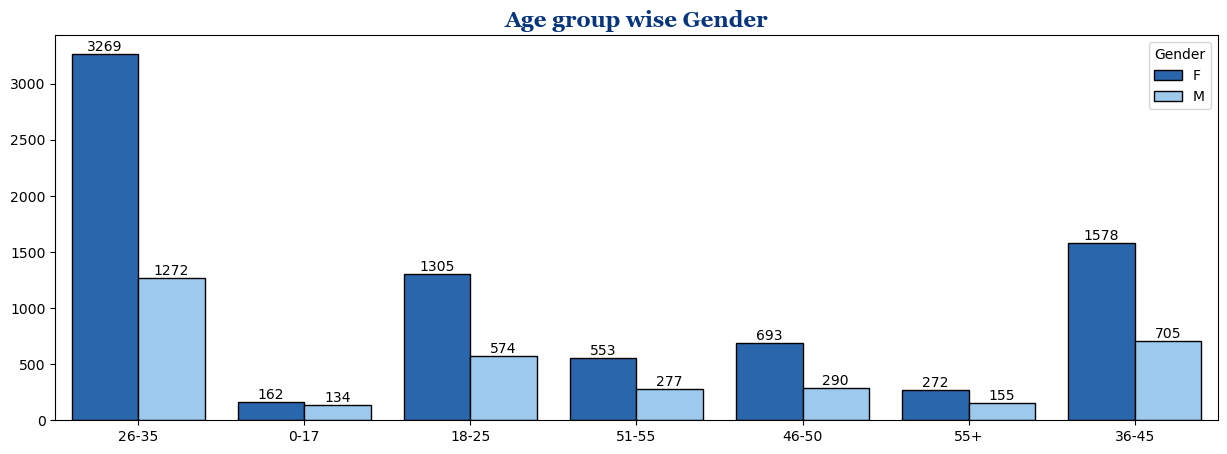

In [87]:
colors = [
    "#E3F2FD",
    "#BBDEFB",
    "#90CAF9",
    "#64B5F6",
    "#42A5F5",
    "#2196F3",
    "#1E88E5",
    "#1565C0",
    "#0D47A1",
]

plt.figure(figsize=(15,5))

A1=sns.countplot(x="Age Group",data=df,hue="Gender",palette=["#1565C0","#90CAF9"],edgecolor="black")

plt.title("Age group wise Gender",family="Georgia",fontsize=16,color="#06357C",fontweight="bold")

plt.xlabel("")

plt.ylabel("")

for y in A1.containers:
    A1.bar_label(y)

plt.show()

**Report:-**

Count plot shows that customers in age group of 26-35 have the highest representation, with females forming a significanr portion of this group.
 
The 0-17 age group has the lowest number of customers.

# **6.2 Line Chart(Product_Category Wise Amount)**

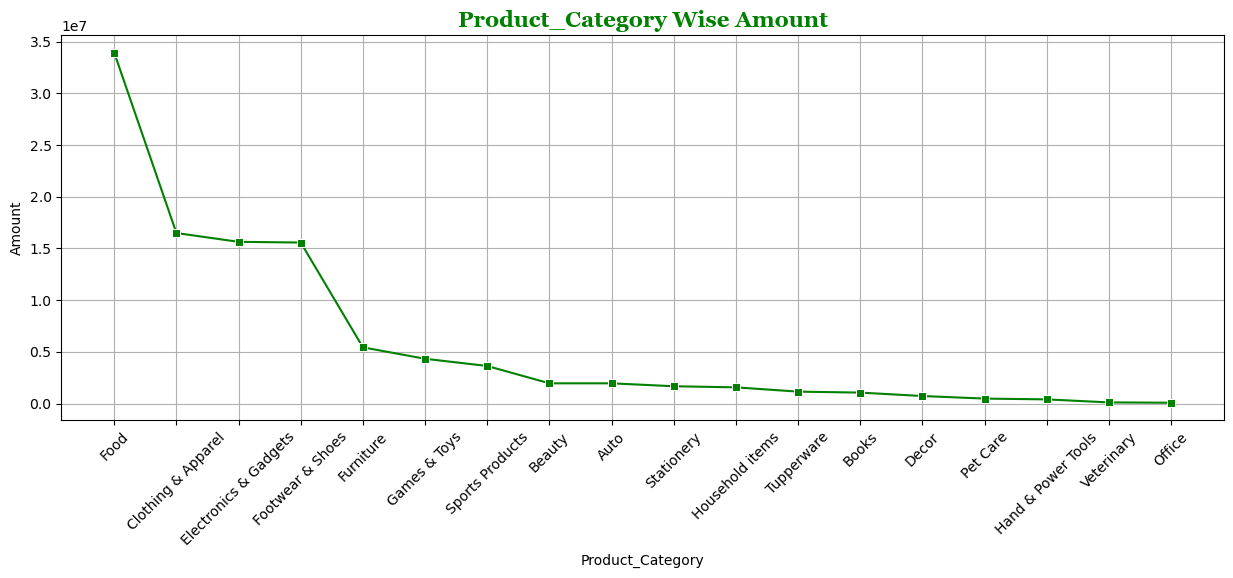

In [88]:
T1=df.groupby("Product_Category",as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)

plt.figure(figsize=(15,5))

sns.lineplot(x=T1["Product_Category"],y=T1["Amount"],data=T1,ci=None,marker="s",color='Green')

plt.title("Product_Category Wise Amount",family="Georgia",fontsize=16,color="Green",fontweight="bold")

plt.xlabel("Product_Category")

plt.ylabel("Amount")

plt.xticks(rotation=45)

plt.grid()

plt.show()

**Report:-**

Line plot shows that Food has highest total sales amount, followed by Clothing & Apparel, Electronics & Gadgets. 

Sales amount decreases significantly across remaining prodcut categories.

# **6.3 Bar Chart(State Wise Amount)**

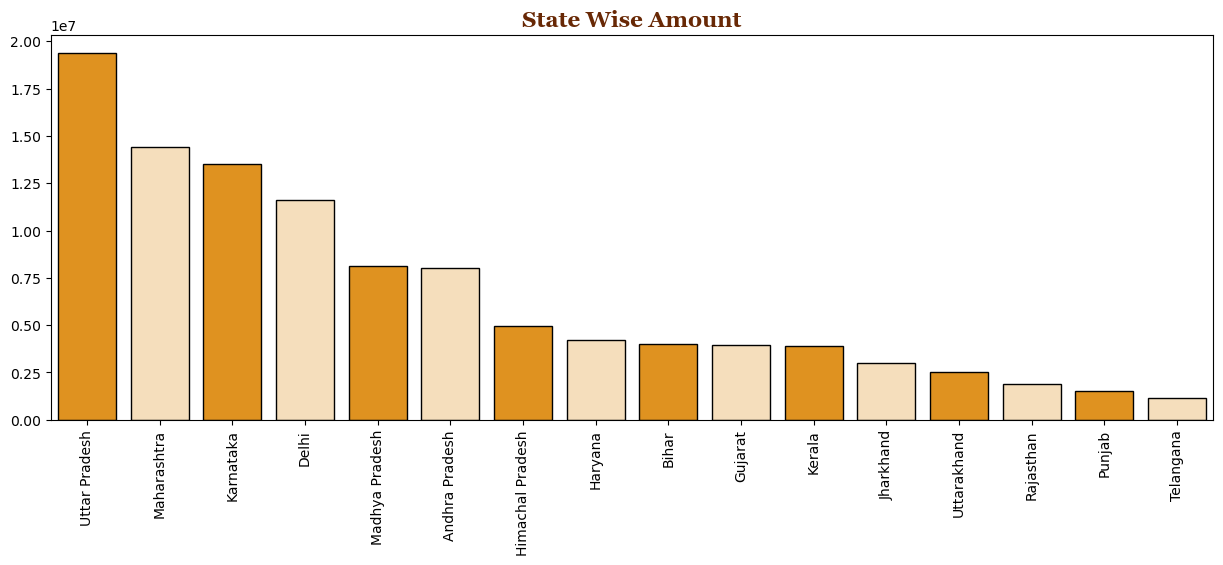

In [89]:
colors = [
    "#FFF3E0",
    "#FFE0B2",
    "#FFCC80",
    "#FFB74D",
    "#FFA726",
    "#FF9800",
    "#FB8C00",
    "#EF6C00",
    "#E65100",
]

T2=df.groupby("State",as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)

plt.figure(figsize=(15,5))

sns.barplot(x=T2["State"],y=T2["Amount"],data=T2,palette=["#FF9800","#FFE0B2"],edgecolor="black")

plt.title("State Wise Amount",family="Georgia",fontsize=16,color="#682805",fontweight="bold")

plt.xticks(rotation=90)

plt.xlabel("")

plt.ylabel("")

plt.show()

**Report:-**

Bar chart shows that Uttar Pradesh generates the highest total sales amount, while Telangana records the lowest.

# **6.4 Pie Chart(Zone Wise Amount)**

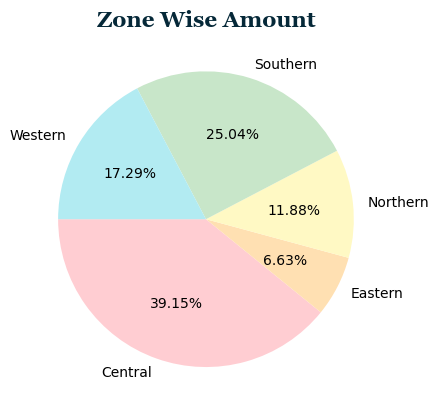

In [90]:
C2=[
    "#FFCDD2",
    "#FFE0B2",
    "#FFF9C4",
    "#C8E6C9",
    "#B2EBF2",
    "#BBDEFB",
    "#D1C4E9",
    "#F8BBD0",
]

T3=df.groupby("Zone",as_index=False)["Amount"].sum()

plt.pie(T3["Amount"],labels=T3["Zone"],autopct="%1.2f%%",startangle=180,colors=C2)

plt.title("Zone Wise Amount",family="Georgia",fontsize=16,color="#052838",fontweight="bold")

plt.show()

**Report:-**

Pie chart shows that Central & Southern zones together cntribute 64.19% of the total sales amount making them the major contributors to overall revenue.

# **6.5 Bar Chart(Sector Wise Orders)**

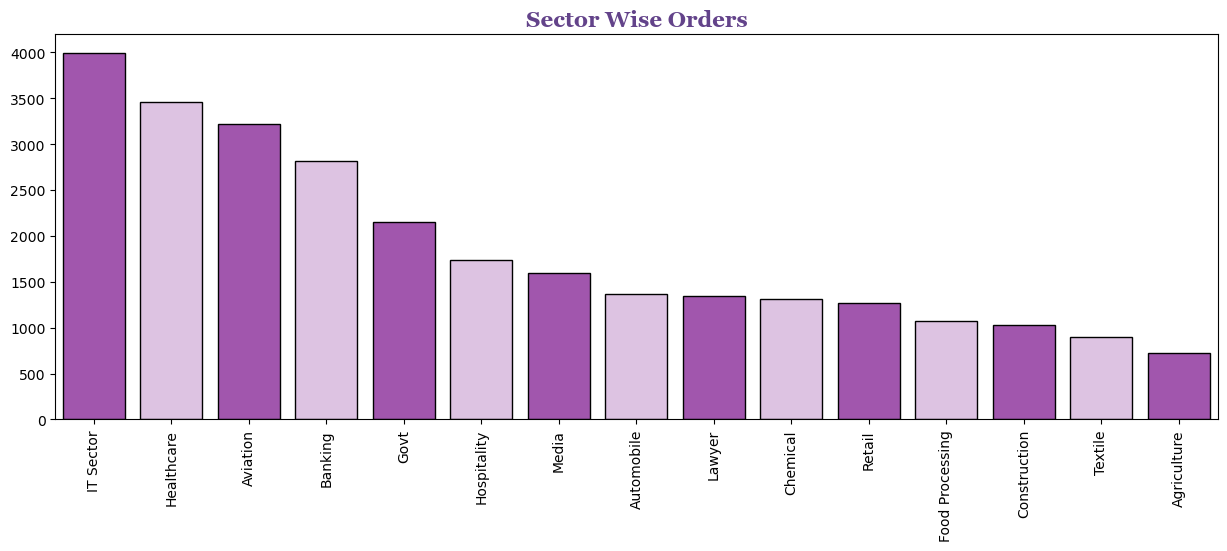

In [91]:
colors = [
    "#F3E5F5",
    "#E1BEE7",
    "#CE93D8",
    "#BA68C8",
    "#AB47BC",
    "#9C27B0",
    "#8E24AA",
    "#6A1B9A",
    "#4A148C",
]

G1=df.groupby("Sector",as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False)

plt.figure(figsize=(15,5))

sns.barplot(x=G1["Sector"],y=G1["Orders"],data=G1,palette=["#AB47BC","#E1BEE7",],edgecolor="black")

plt.title("Sector Wise Orders",family="Georgia",fontsize=16,color="#63438A",fontweight="bold")

plt.xticks(rotation=90)

plt.xlabel("")

plt.ylabel("")

plt.show()

**Report:-**

Bar chart indicates that customers from IT sector placed the highest no. of orders whereas Agriculture sector recorded the lowest number of orders.

# **6.6 Line Plot(Zone Wise Amount)**

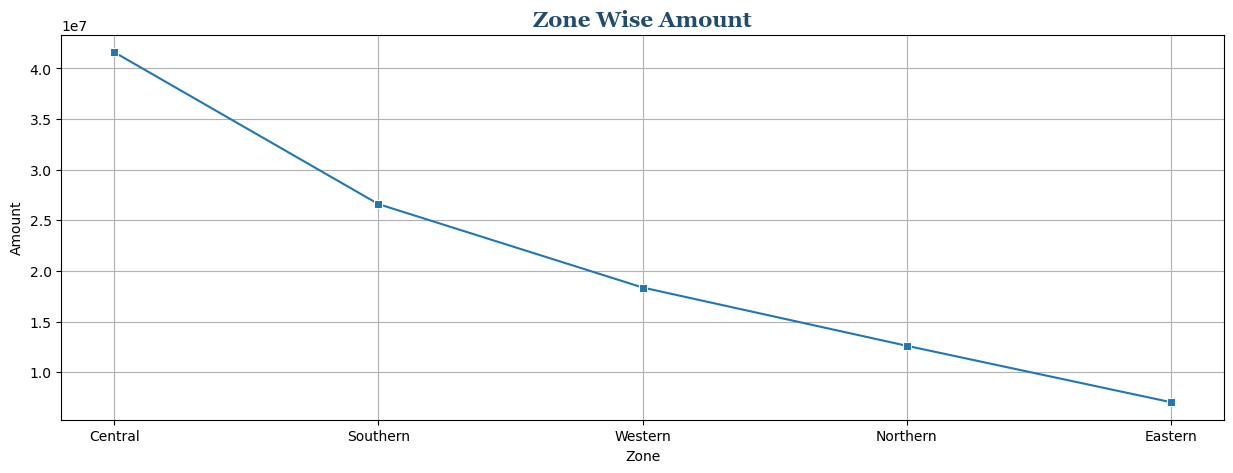

In [92]:
G2=df.groupby("Zone",as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)

plt.figure(figsize=(15,5))

sns.lineplot(x=G2["Zone"],y=G2["Amount"],data=G2,ci=None,marker="s")

plt.title("Zone Wise Amount",family="Georgia",fontsize=16,color="#204C70",fontweight="bold")

plt.xlabel("Zone")

plt.ylabel("Amount")

plt.grid()

plt.show()

**Report:-**

Line plot shows that Central Zone has highest total sales amount, followed by Southern zone, while the Eastern zone records the lowest sales amount.

# **6.7 Pie Chart(Product_Category Wise Orders)**

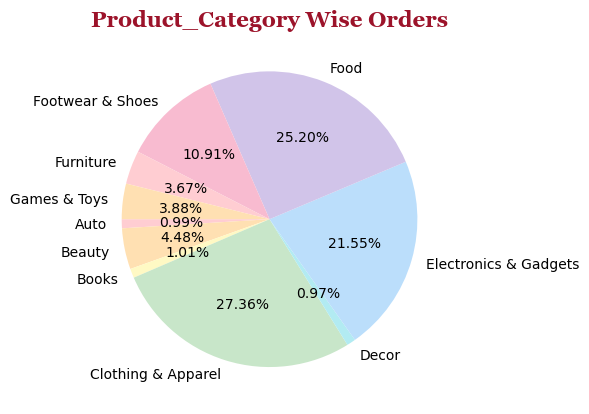

In [93]:
C2 = [
    "#FFCDD2",
    "#FFE0B2",
    "#FFF9C4",
    "#C8E6C9",
    "#B2EBF2",
    "#BBDEFB",
    "#D1C4E9",
    "#F8BBD0",
]

G3=df.groupby("Product_Category",as_index=False)["Orders"].sum().head(10)

plt.pie(G3["Orders"],labels=G3["Product_Category"],autopct="%1.2f%%",startangle=180,colors=C2)

plt.title("Product_Category Wise Orders",family="Georgia",fontsize=16,color="#9C132A",fontweight="bold")

plt.show()

**Report:-**

Pie chart shows that Clothing & Apparel, Electronics & Gadgets and Food together account for 74.11% of total orders, making them the major contributing product categories.

# **7. Conclusion**

1. Target marketing campaigns on 26-35 age group female customers.

2. Priortize high performing sectors such as IT, Healthcare & Aviation.

3. Introduce targeted offers & campaigns in low performing states.

4. Explore growth opportunities in Eastern, Western & Northen zones.

5. Review low performing catrgories to improve sales.

# **8. Cleaned dataset**

In [94]:
df.to_csv("Clean data file.csv",index=False)